# 🎲 What we’ll visualize
Two different experiments:

- **Bernoulli (p = 0.5)**
Simulate 10,000 individual coin flips → histogram of 0s and 1s.

- **Binomial (n = 10, p = 0.5)**
Simulate 10,000 groups of 10 flips → histogram of counts 0–10.

This shows:
- Bernoulli → only two bars (0 and 1).
- Binomial → a full distribution (0 through 10), shaped like a bell.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom

In [2]:
# --- Simulation ---
N = 10_000

In [3]:
# Benoulli: one flip per trial
bern_samples = bernoulli.rvs(p=0.5, size=N)
bern_samples

array([1, 0, 0, ..., 1, 0, 0], shape=(10000,))

In [4]:
# Binomial: 10 flips per trial, count successes
binom_samples = binom.rvs(n=10, p=0.5, size=N)
binom_samples

array([8, 2, 5, ..., 7, 5, 2], shape=(10000,))

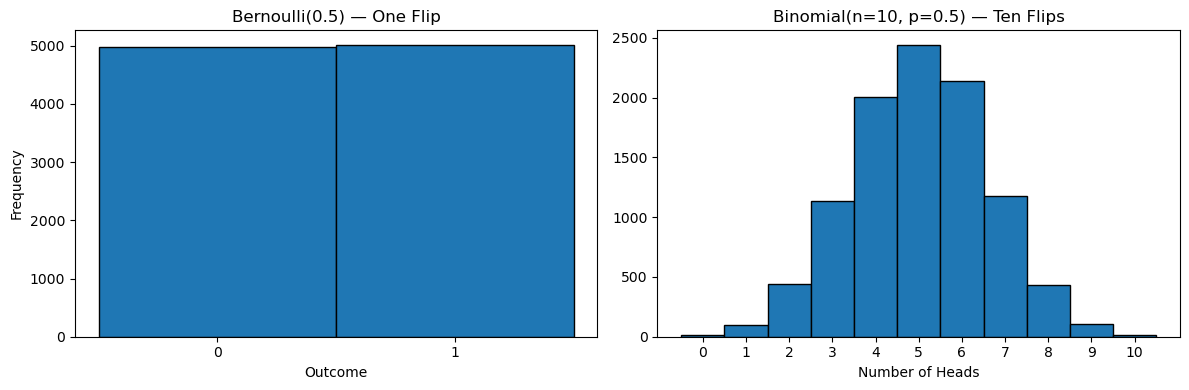

In [8]:
# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Bernoulli histogram
axes[0].hist(bern_samples, bins=[-0.5, 0.5, 1.5], edgecolor='black')
axes[0].set_xticks([0, 1])
axes[0].set_title("Bernoulli(0.5) — One Flip")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Frequency")

# Binomial histogram
axes[1].hist(binom_samples, bins=np.arange(-0.5, 11.5, 1), edgecolor='black')
axes[1].set_xticks(range(11))
axes[1].set_title("Binomial(n=10, p=0.5) — Ten Flips")
axes[1].set_xlabel("Number of Heads")

plt.tight_layout()
plt.show()


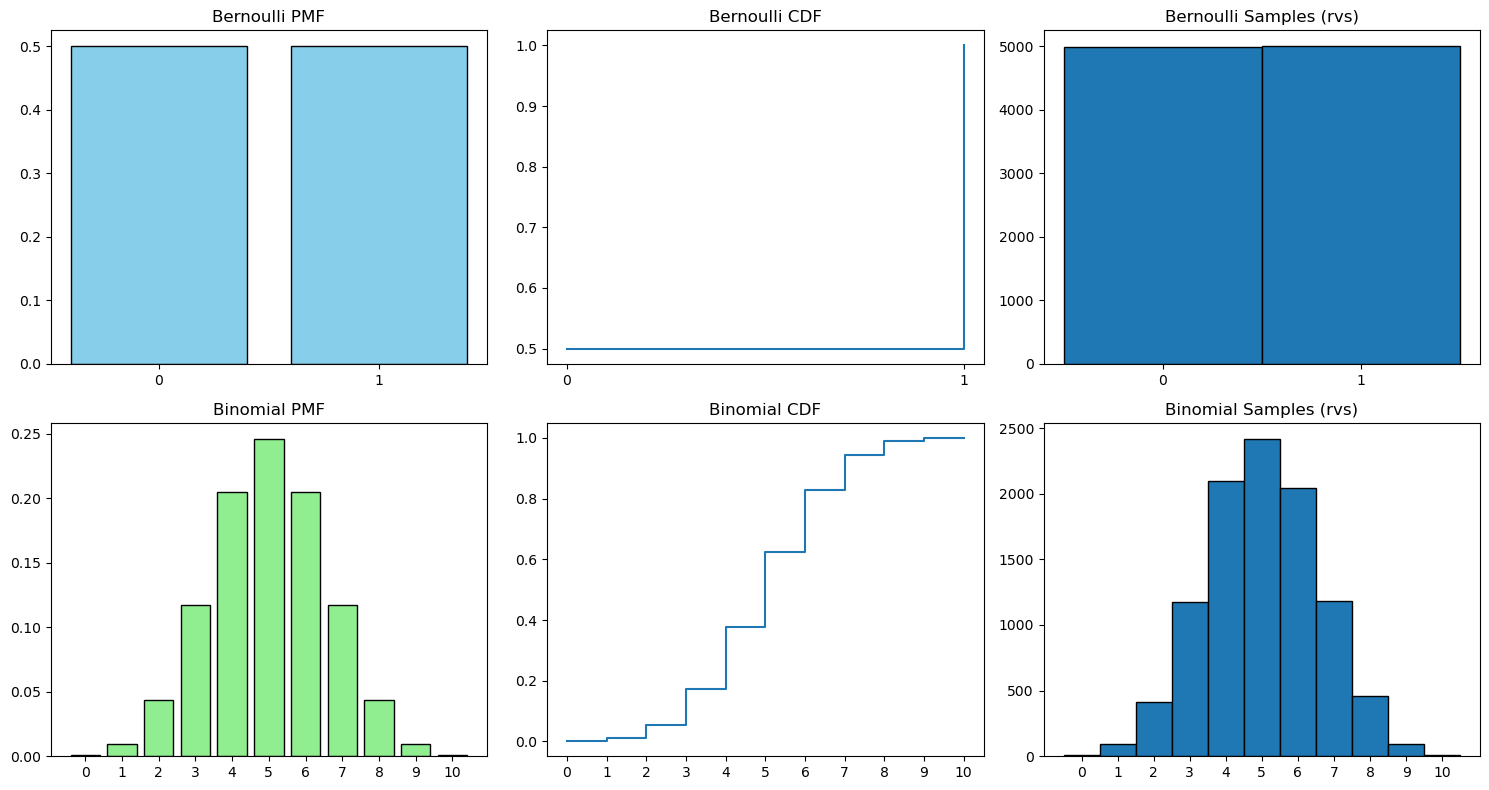

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom

# Parameters
p = 0.5
n = 10
N = 10000

# Simulations
bern_samples = bernoulli.rvs(p, size=N)
binom_samples = binom.rvs(n, p, size=N)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# -------------------------
# Bernoulli PMF
k_vals_bern = [0, 1]
axes[0,0].bar(k_vals_bern, bernoulli.pmf(k_vals_bern, p), color='skyblue', edgecolor='black')
axes[0,0].set_title("Bernoulli PMF")
axes[0,0].set_xticks([0,1])

# Bernoulli CDF
axes[0,1].step(k_vals_bern, bernoulli.cdf(k_vals_bern, p), where='post')
axes[0,1].set_title("Bernoulli CDF")
axes[0,1].set_xticks([0,1])

# Bernoulli Samples
axes[0,2].hist(bern_samples, bins=[-0.5,0.5,1.5], edgecolor='black')
axes[0,2].set_title("Bernoulli Samples (rvs)")
axes[0,2].set_xticks([0,1])

# -------------------------
# Binomial PMF
k_vals_binom = np.arange(0, n+1)
axes[1,0].bar(k_vals_binom, binom.pmf(k_vals_binom, n, p), color='lightgreen', edgecolor='black')
axes[1,0].set_title("Binomial PMF")
axes[1,0].set_xticks(k_vals_binom)

# Binomial CDF
axes[1,1].step(k_vals_binom, binom.cdf(k_vals_binom, n, p), where='post')
axes[1,1].set_title("Binomial CDF")
axes[1,1].set_xticks(k_vals_binom)

# Binomial Samples
axes[1,2].hist(binom_samples, bins=np.arange(-0.5, n+1.5, 1), edgecolor='black')
axes[1,2].set_title("Binomial Samples (rvs)")
axes[1,2].set_xticks(k_vals_binom)

plt.tight_layout()
plt.show()